In [1]:
# =====================================================
# ASSIGNMENT 8 - Linear Regression (SIMPLEST VERSION)
# Dataset: Boston Housing (built-in sklearn)
# =====================================================

# STEP 1: Import karo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing  # built-in dataset!
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
# STEP 2: Load Dataset (No download needed!)
# Sirf ye ek line — direct DataFrame ban jaata hai!
data = fetch_california_housing(as_frame=True)
df = data.frame   # ready-made DataFrame!
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [5]:
print("Dataset Loaded!")
print("Shape:", df.shape)
print(df.head())

Dataset Loaded!
Shape: (20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [7]:
# STEP 3: X aur Y select karo
X = df.drop('MedHouseVal', axis=1)   # ← 'Price' nahi 'MedHouseVal' hai!
Y = df['MedHouseVal']                 # ← target column

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (20640, 8)
Y shape: (20640,)


In [8]:
# STEP 4: Train aur Test mein baanto
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print("\nTraining size:", X_train.shape)
print("Testing size:", X_test.shape)


Training size: (16512, 8)
Testing size: (4128, 8)


In [9]:
# STEP 5: Model banao aur train karo
model = LinearRegression()
model.fit(X_train, Y_train)
print("\nModel Trained!")


Model Trained!


In [10]:
# STEP 6: Prediction
Y_pred = model.predict(X_test)

print("Predicted Prices:", Y_pred[:5])
print("Actual Prices:", list(Y_test[:5]))

Predicted Prices: [0.71912284 1.76401657 2.70965883 2.83892593 2.60465725]
Actual Prices: [0.477, 0.458, 5.00001, 2.186, 2.78]


In [11]:
# STEP 7: Accuracy check karo
mse  = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(Y_test, Y_pred)

print("\n--- Model Accuracy ---")
print("MSE :", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("R2 Score:", round(r2, 2))



--- Model Accuracy ---
MSE : 0.56
RMSE: 0.75
R2 Score: 0.58


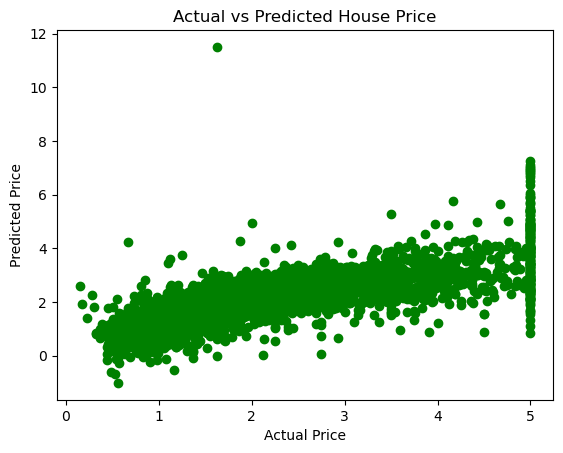

In [12]:
# STEP 8: Graph banao
plt.scatter(Y_test, Y_pred, color='green')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Price")
plt.show()